##### Disease Prediction using Machine Learning 
Logistic Regression vs Random Forest - Amena  M. Shumi 06.03.2026

## Table of Contents

- [Phase 1 — Project Introduction](#phase-1--project-introduction)
  - [1.1 — Project Overview](#11--project-overview)
  - [1.2 — Problem Statement](#12--problem-statement)
  - [1.3 — Dataset Description](#13--dataset-description)

- [Phase 2 — Data Exploration & Preparation](#phase-2--data-exploration--preparation)
  - [2.1 — Data Loading](#21--data-loading)
  - [2.2 — Exploratory Data Analysis (EDA)](#22--exploratory-data-analysis-eda)
  - [2.3 — Feature Engineering](#23--feature-engineering)

- [Phase 3 — Model Development](#phase-3--model-development)
  - [3.1 — Logistic Regression (Multinomial)](#31--logistic-regression-multinomial)
  - [3.2 — Random Forest Classifier](#32--random-forest-classifier)

- [Phase 4 — Results & Evaluation](#phase-4--results--evaluation)
  - [4.1 — Results](#41--results)
  - [4.2 — Key Insights](#42--key-insights)

- [Phase 5 — Project Wrap-Up](#phase-5--project-wrap-up)
  - [5.1 — Limitations](#51--limitations)
  - [5.2 — Conclusion](#52--conclusion)

## Phase 1 — Project Introduction

### 1.1 — Project Overview

The goal is to build a machine learning model that helps doctors diagnose illnesses early by analyzing a patient's symptoms. By training the system on a large dataset of symptoms and their matching diseases, the model learns to spot patterns and predict what might be making a patient sick.

### 1.2 — Problem Statement

In modern healthcare systems, hospitals and clinics are overcrowded, with long patient wait times, fewer doctors, and 
medical staff. Patients come to the doctor with complaints about their problems to the doctor, and the doctor checks
manually, cross-referencing a patient's self-reported symptoms to finalize the disease.
as well as takes time, human error, and cost for all medical tests.

. 


### 1.3 — Dataset Description


Dataset Name: Disease Prediction Using Machine Learning

Dataset Source: Kaggle,    https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning?resource=download
               
The dataset contains symptom-based records associated with specific diseases.

Dataset Characteristics
Attribute	Description
Number of Features	132 symptoms
Target Variable	prognosis (disease name)
Feature Type	Binary (0 = absent, 1 = present)
Dataset Files	Training.csv, Testing.csv

Example Features
itching
skin_rash
headache
nausea
vomiting
fatigue
high_fever
Target Variable

The prognosis column represents the diagnosed disease for each symptom combination.

## Phase 2 — Data Exploration & Preparation

### 2.1 — Data Loading

In [209]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import json
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.simplefilter("ignore", FutureWarning)

#### Imports and setup
Save all images and summaries into `../results/amena_results` (relative to this notebook in `notebooks/`).

In [210]:
DATA_DIR = Path('../data/raw')
OUTPUT_DIR = Path('../results/amena_results')
FIG_DIR = OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [211]:
train_df = pd.read_csv(DATA_DIR / 'Training.csv')
test_df = pd.read_csv(DATA_DIR / 'Testing.csv')

The training dataset is used to train the models, while the testing dataset evaluates model performance.

### 2.2 — Exploratory Data Analysis (EDA)

In [212]:
print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('Target classes:', train_df['prognosis'].nunique())
print('DATA_DIR:', DATA_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())
train_df.head()

Train shape: (4920, 133)
Test shape : (42, 133)
Target classes: 41
DATA_DIR: C:\Users\amena\DSI\Disease_Prediction_With_ML\data\raw
OUTPUT_DIR: C:\Users\amena\DSI\Disease_Prediction_With_ML\results\amena_results


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [213]:
test_df.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction


In [214]:
X_train = train_df.drop(columns=['prognosis'])
y_train = train_df['prognosis']
X_test = test_df.drop(columns=['prognosis'])
y_test = test_df['prognosis']

# show dataset columns
print(train_df.columns)
print(test_df.columns)

# basic dataset information
print("Number of symptoms:", train_df.shape[1] - 1)
print("Number of unique diseases:", train_df["prognosis"].nunique())

print(train_df["prognosis"].value_counts())   
train_df.info()                              

# null values
null_train_total = int(train_df.isna().sum().sum())
null_test_total = int(test_df.isna().sum().sum())

# duplicate checks
train_duplicates = int(train_df.duplicated().sum())
test_duplicates = int(test_df.duplicated().sum())

# feature statistics
feature_unique_values = [int(v) for v in sorted(pd.unique(X_train.values.ravel()))]

class_counts = y_train.value_counts().sort_values(ascending=False)

symptom_count_per_record = X_train.sum(axis=1)

feature_prevalence = X_train.mean().sort_values(ascending=False)
class_distribution = train_df["prognosis"].value_counts()

# EDA summary
EDA_summary = {
    "null_train_total": null_train_total,
    "null_test_total": null_test_total,
    "train_duplicates": train_duplicates,
    "test_duplicates": test_duplicates,
    "num_symptoms": int(train_df.shape[1] - 1),
    "num_unique_diseases": int(train_df["prognosis"].nunique()),
    "feature_unique_values": feature_unique_values,
    "n_classes": int(class_counts.shape[0]),
    "class_min_count": int(class_counts.min()),
    "class_max_count": int(class_counts.max()),
    "class_mean_count": float(class_counts.mean()),
    "symptoms_per_record_min": int(symptom_count_per_record.min()),
    "symptoms_per_record_max": int(symptom_count_per_record.max()),
    "symptoms_per_record_mean": float(symptom_count_per_record.mean()),
    "symptoms_per_record_median": float(symptom_count_per_record.median()),
    "feature_prevalence_mean": float(feature_prevalence.mean()),
    "feature_prevalence_max": float(feature_prevalence.max()),
    "class_distribution": class_distribution.to_dict()
}

OUTPUT_DIR = Path("../results/amena_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "EDA_summary.json").write_text(json.dumps(EDA_summary, indent=2))
print(json.dumps(EDA_summary, indent=2))
pd.DataFrame([EDA_summary])

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'blackheads', 'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis'],
      dtype='str', length=133)
Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'blackheads', 'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis'],
      dtype='str', length=133)
Number of symptoms: 132
Number of unique diseases: 41
prognosis
Fungal infection                           120
Allergy                                    120
GE

,null_train_total,null_test_total,train_duplicates,test_duplicates,num_symptoms,num_unique_diseases,feature_unique_values,n_classes,class_min_count,class_max_count,class_mean_count,symptoms_per_record_min,symptoms_per_record_max,symptoms_per_record_mean,symptoms_per_record_median,feature_prevalence_mean,feature_prevalence_max,class_distribution
0,0,0,4616,0,132,41,"[0, 1]",41,120,120,120.0,3,17,7.44878,6.0,0.05643,0.392683,"{'Fungal infection': 120, 'Allergy': 120, 'GER..."


In [215]:
#Data Cleaning check : During preprocessing  unnecessary columns were remove

if train_df.isna().values.any():
    print("NaN values found")
else:
    print("No NaN values")

No NaN values


###  EDA plots

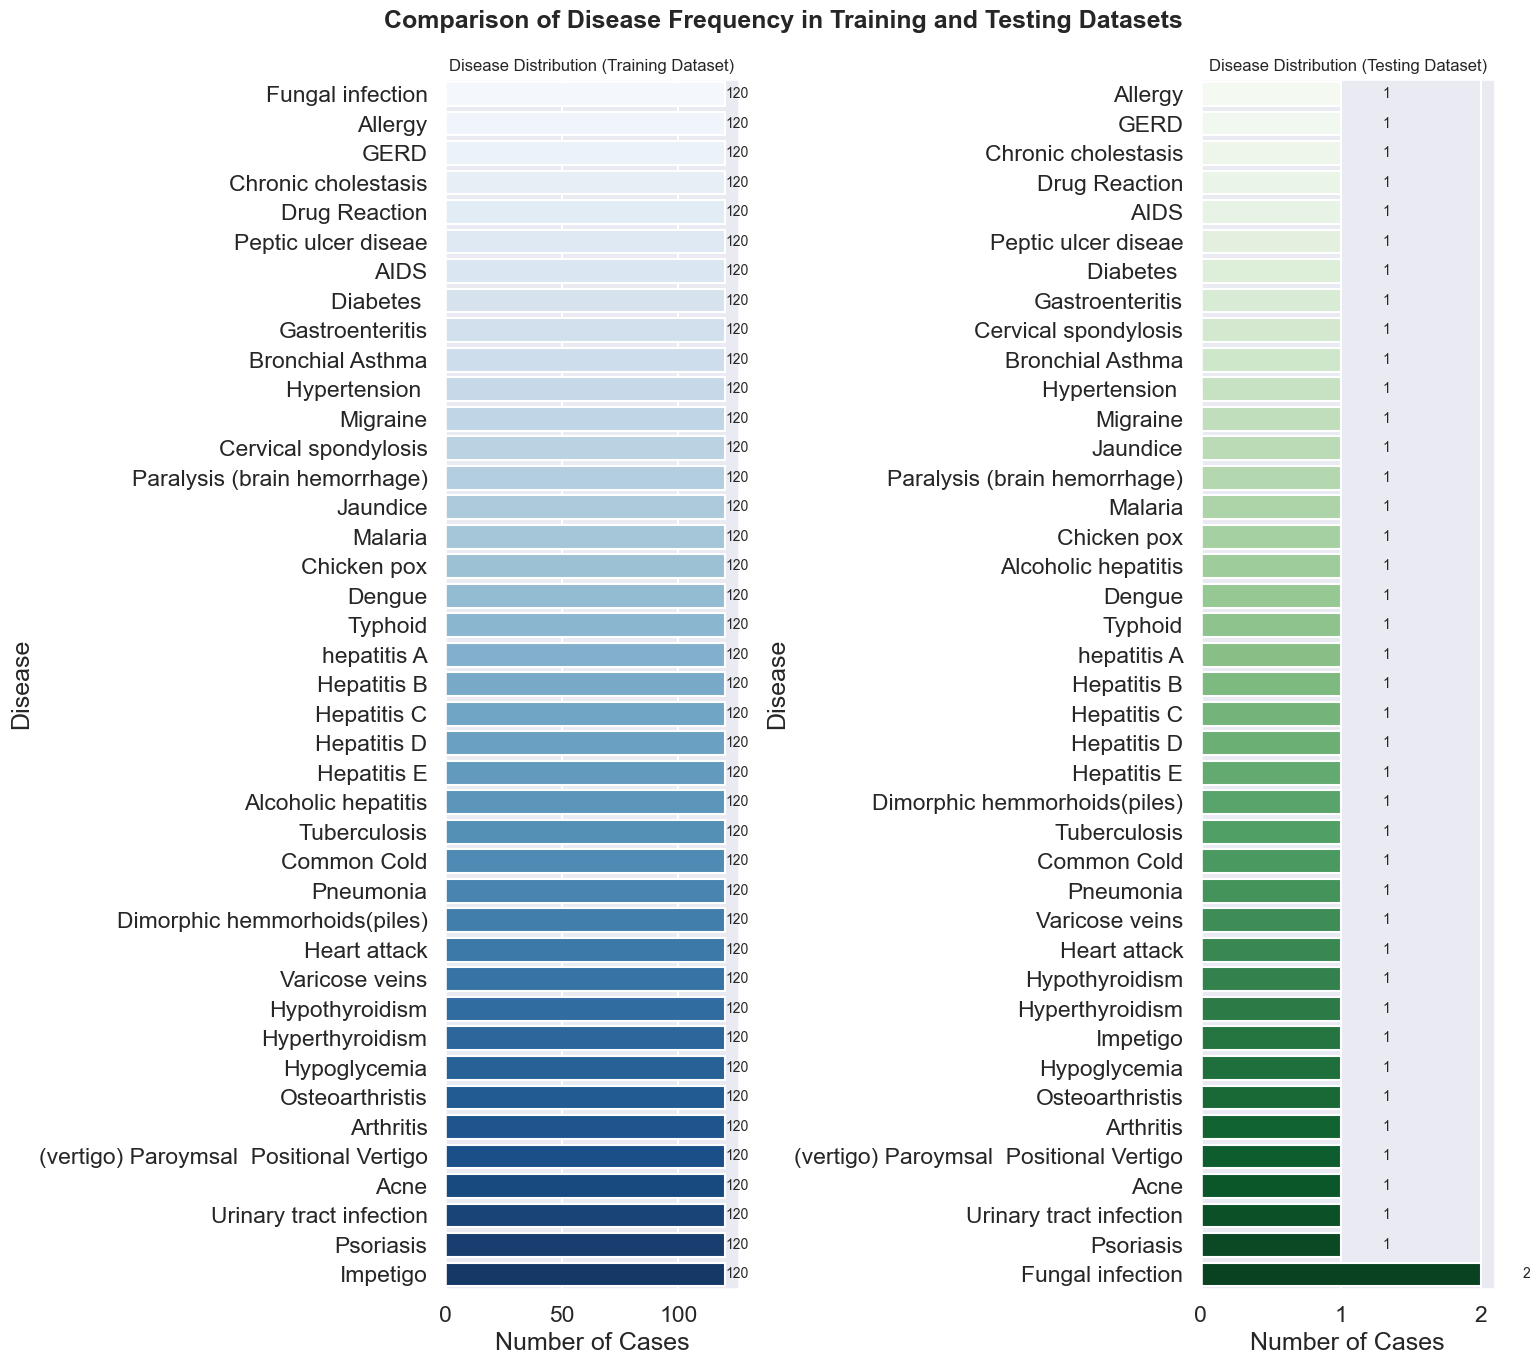

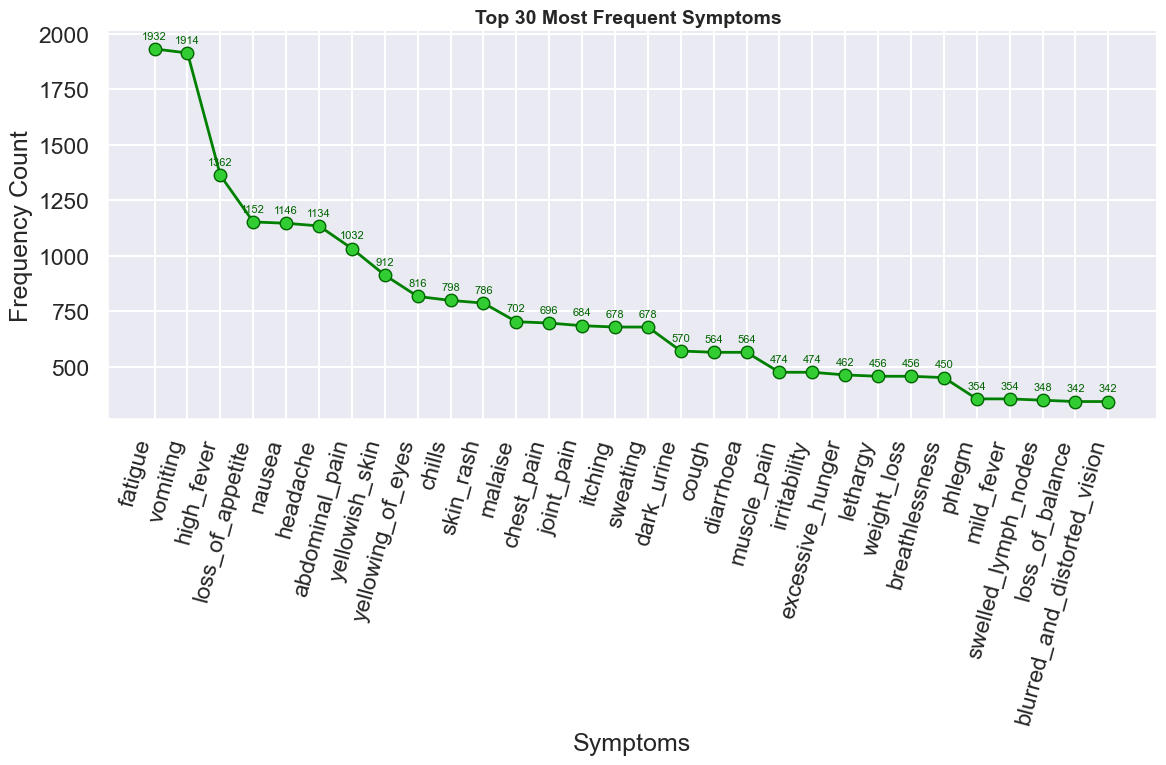

In [216]:
sns.set_theme(style="darkgrid", context="talk")

# Compute disease counts
train_counts = train_df["prognosis"].value_counts().sort_values()
test_counts = test_df["prognosis"].value_counts().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(16,14))

# Training dataset visualization
sns.barplot(
    x=train_counts.values,
    y=train_counts.index,
    palette="Blues",
    ax=axes[0]
)

axes[0].set_title("Disease Distribution (Training Dataset)", fontsize=12)
axes[0].set_xlabel("Number of Cases")
axes[0].set_ylabel("Disease")
for i, value in enumerate(train_counts.values):
    axes[0].text(value + 0.3, i, f"{value}", va="center", fontsize=10)

# Testing dataset visualization
sns.barplot(
    x=test_counts.values,
    y=test_counts.index,
    palette="Greens",
    ax=axes[1]
)

axes[1].set_title("Disease Distribution (Testing Dataset)", fontsize=12)
axes[1].set_xlabel("Number of Cases")
axes[1].set_ylabel("Disease")
for i, value in enumerate(test_counts.values):
    axes[1].text(value + 0.3, i, f"{value}", va="center", fontsize=10)
fig.suptitle(
    "Comparison of Disease Frequency in Training and Testing Datasets",
    fontsize=18,
    weight="bold"
)
plt.tight_layout()
fig.savefig(FIG_DIR / "eda_disease_distribution.png", dpi=160)
plt.show()


#B)"Top 30 Most Frequent Symptoms
symptom_counts = train_df.drop(columns="prognosis").sum()
top_symptoms_line = symptom_counts.sort_values(ascending=False).head(30)
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(
    top_symptoms_line.index,
    top_symptoms_line.values,
    marker="o",
    linewidth=2,
    color="green",         
    markerfacecolor="limegreen",
    markeredgecolor="darkgreen"
)
ax.set_title("Top 30 Most Frequent Symptoms ", fontsize=14, weight="bold")
ax.set_xlabel("Symptoms")
ax.set_ylabel("Frequency Count")
# Add numbers
for i, y in enumerate(top_symptoms_line.values):
    ax.annotate(
        f"{int(y)}",
        (i, y),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        va="bottom",
        fontsize=8,
        color="darkgreen"
    )
# numeric x positions
ax.set_xticks(range(len(top_symptoms_line.index)))
ax.set_xticklabels(top_symptoms_line.index, rotation=75, ha="right")
sns.despine()
plt.tight_layout()
fig.savefig(FIG_DIR / "eda_top_symptoms_line.png", dpi=160)
plt.show()


Symptom Frequency Analysis  : 
The most frequently occurring symptoms were identified by summing each symptom column.
Visualization included the top 30 most common symptoms and a horizontal bar chart representation. This helps identify symptoms that strongly contribute to disease prediction.

### 2.3 — Feature Engineering

Machine learning models require numerical inputs.

In [217]:
label_encode = LabelEncoder()
y_train_enc = label_encode.fit_transform(y_train)
y_test_enc = label_encode.transform(y_test)

print('Encoded classes:', len(label_encode.classes_))
print(label_encode.transform(["Fungal infection"]))

Encoded classes: 41
[15]


## Phase 3 — Model Development

Two machine learning models were implemented .

Logistic Regression is a widely used classification algorithm suitable for multi-class problems.

In [218]:
# Model configuration:
multinomial_model = LogisticRegression(
    solver='lbfgs',  ##lbfgs automatically uses multinomial for multi-class problems
    max_iter=1000, 
    C=1.0, 
    random_state=42
)
multinomial_model.fit(X_train, y_train_enc)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [219]:
# # Predict & Evaluate
y_pred = multinomial_model.predict(X_test) # Predict
lr_accuracy = accuracy_score(y_test_enc, y_pred)
lr_report = classification_report(y_test_enc, y_pred, output_dict=True, zero_division=0)

print("Logistic Regression Accuracy:", lr_accuracy)
print(classification_report(y_test_enc, y_pred))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00    

In [220]:
# Save
lr_summary = {
    "model": "Logistic Regression",
    "accuracy": float(lr_accuracy),
    "macro_f1": float(lr_report["macro avg"]["f1-score"])
}

(OUTPUT_DIR / "logistic_regression_metrics.json").write_text(
    json.dumps(lr_summary, indent=2)
)

pd.DataFrame(lr_report).T.to_csv(
    OUTPUT_DIR / "logistic_regression_report.csv"
)

This model serves as a baseline classifieThis dataset is known to give very high accuracy because symptoms map almost perfectly to diseases. The model achieved 100% accuracy on the testing dataset.
This is expected because the dataset contains clear symptom–disease relationships and a small test set.

### 3.2 — Random Forest Classifier

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.

In [221]:
# Random Forest Initialization
#-------------------------------------------------------
RandomForest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForest_model,
    X_train,
    y_train_enc,
    cv=cv,
    scoring="accuracy"
)

print("CV scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

# Hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid.fit(X_train, y_train_enc)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)


# Final Model
best_random_forest = grid.best_estimator_

y_pred_RandomForest = best_random_forest.predict(X_test)

# Model Evaluation
RandomForest_accuracy = accuracy_score(y_test_enc, y_pred_RandomForest)

RandomForest_report = classification_report(
    y_test_enc,
    y_pred_RandomForest,
    output_dict=True,
    zero_division=0
)

print("Random Forest Accuracy:", RandomForest_accuracy)
print(classification_report(y_test_enc, y_pred_RandomForest))


RandomForest_summary = {
    "model": "Random Forest",
    "best_params": grid.best_params_,
    "cv_mean_accuracy": float(cv_scores.mean()),
    "test_accuracy": float(RandomForest_accuracy),
    "macro_f1": float(RandomForest_report["macro avg"]["f1-score"])
}

(OUTPUT_DIR / "random_forest_metrics.json").write_text(
    json.dumps(RandomForest_summary, indent=2)
)

pd.DataFrame(RandomForest_report).T.to_csv(
    OUTPUT_DIR / "random_forest_classification_report.csv"
)



CV scores: [1. 1. 1. 1. 1.]
Mean CV score: 1.0
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 1.0
Random Forest Accuracy: 0.9761904761904762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         

## Phase 4 — Results & Evaluation

### 4.1 — Results

Both models  predicted diseases based on symptom inputs.

In [222]:
results_df = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_test_enc, y_pred),
        accuracy_score(y_test_enc, y_pred_RandomForest)
    ],
    "Precision": [
        precision_score(y_test_enc, y_pred, average="weighted"),
        precision_score(y_test_enc, y_pred_RandomForest, average="weighted")
    ],
    "Recall": [
        recall_score(y_test_enc, y_pred, average="weighted"),
        recall_score(y_test_enc, y_pred_RandomForest, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test_enc, y_pred, average="weighted"),
        f1_score(y_test_enc, y_pred_RandomForest, average="weighted")
    ]
}, index=["Logistic Regression", "Random Forest"])

results_df


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,1.00000,1.000000,1.00000,1.00000
Random Forest,0.97619,0.988095,0.97619,0.97619


##### Model Results polt

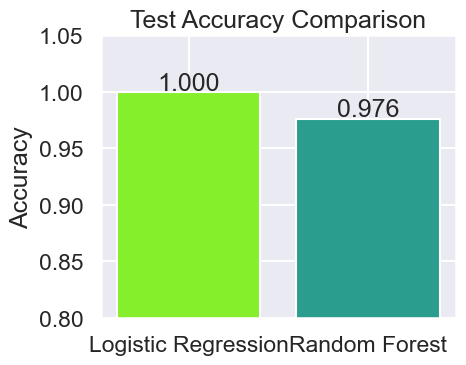

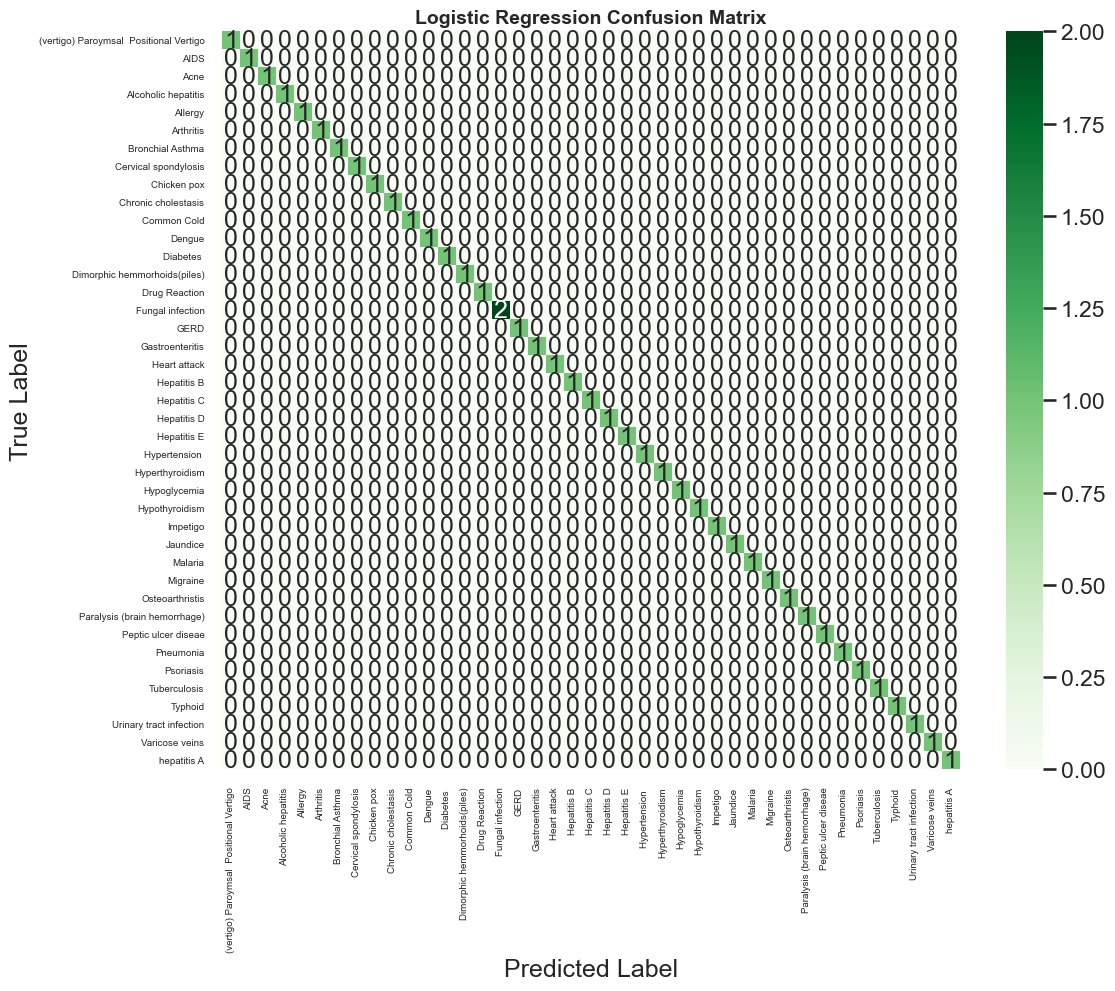

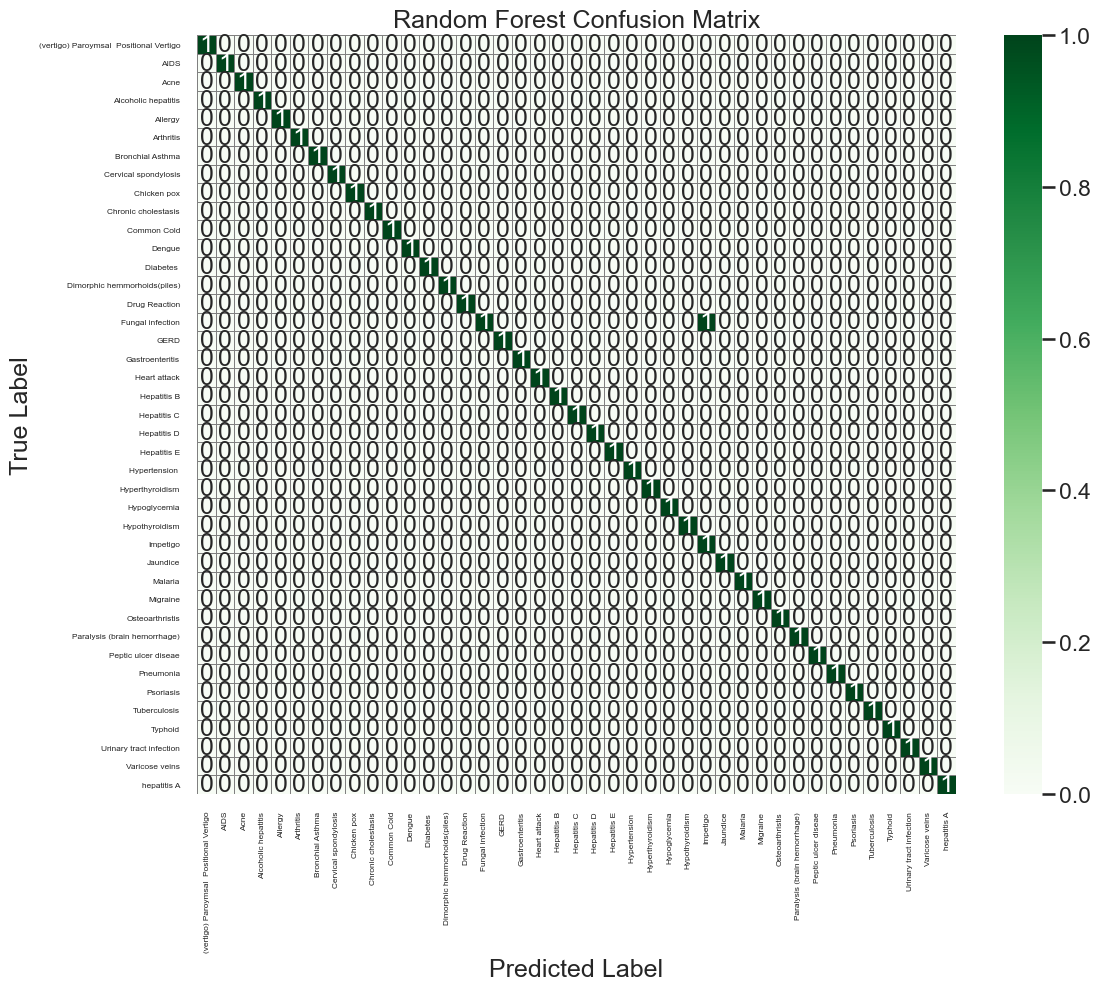

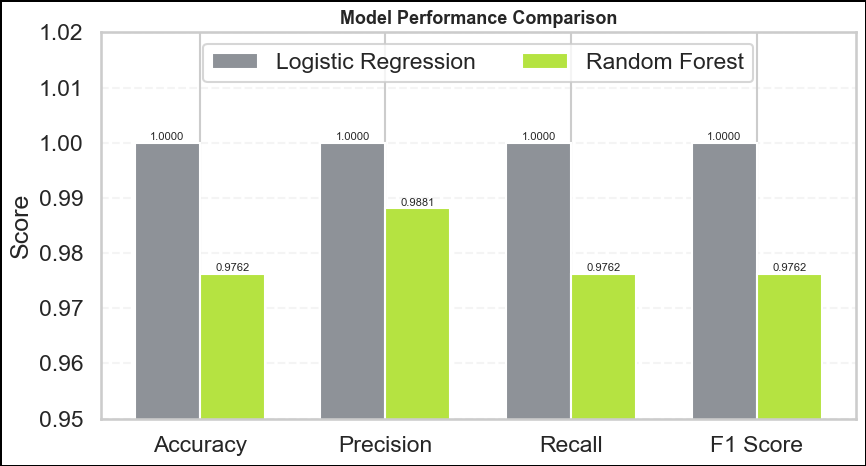

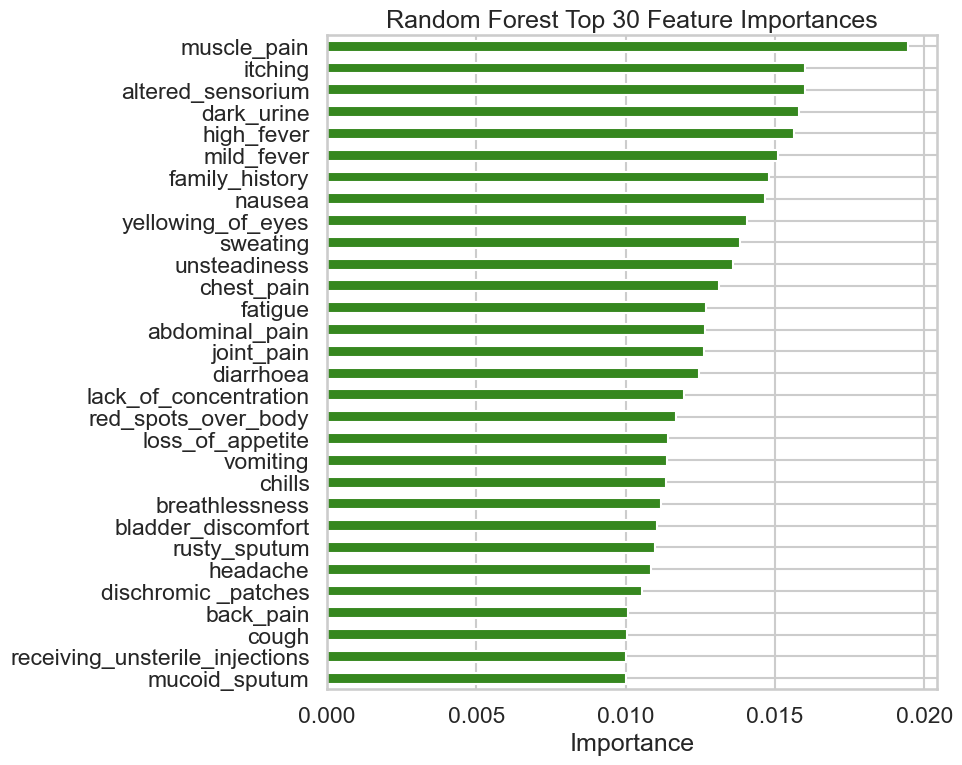

muscle_pain          0.019439
itching              0.016014
altered_sensorium    0.016001
dark_urine           0.015811
high_fever           0.015623
dtype: float64

In [223]:
fig, ax = plt.subplots(figsize=(5,4))

models = ["Logistic Regression", "Random Forest"]
accs = [accuracy_score(y_test_enc, y_pred),
        accuracy_score(y_test_enc, y_pred_RandomForest)]

bars = ax.bar(models, accs, color=["#86ef2b", "#2a9d8f"])

# value labels
for bar, value in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.002,
        f"{value:.3f}",
        ha="center"
    )

ax.set_title("Test Accuracy Comparison")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.8, 1.05)

fig.tight_layout()

fig.savefig(OUTPUT_DIR / "model_accuracy_comparison.png", dpi=160)
plt.show()

#------------------------------------------------------------------------------
# Confusion Matrix Plot -Logistic Regression)
cm = confusion_matrix(y_test_enc, y_pred)

fig, ax = plt.subplots(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Greens",
    cbar=True,
    square=True,
    annot=True,          
    fmt="d",              
    xticklabels=label_encode.classes_,
    yticklabels=label_encode.classes_,
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix", fontsize=14, weight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "logistic_regression_confusion_matrix.png",
    dpi=160
)

plt.show()

#--------------------------------------------------------------------------------------------------------
# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test_enc, y_pred_RandomForest)

fig, ax = plt.subplots(figsize=(12,10))

sns.heatmap(
    cm_rf,
    cmap="Greens",
    annot=True,
    fmt="d",
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="gray",
    xticklabels=label_encode.classes_,
    yticklabels=label_encode.classes_,
    ax=ax
)

ax.set_title("Random Forest Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.tick_params(axis="y", labelsize=6)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "random_forest_confusion_matrix.png",
    dpi=160
)

plt.show()


#-------------------------------------------------------------------------------
## Confusion Matrix
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

log_vals = [results_df.loc["Logistic Regression", m] for m in metrics]
rf_vals  = [results_df.loc["Random Forest", m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(9,5))
bars1 = ax.bar(x - width/2, log_vals, width,
               label="Logistic Regression",
               color="#8E9298")

bars2 = ax.bar(x + width/2, rf_vals, width,
               label="Random Forest",
               color="#B5E341")

# axis labels
ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(0.95, 1.02)
ax.set_ylabel("Score")
ax.grid(axis='y', linestyle='--', alpha=0.2)


ax.set_title("Model Performance Comparison",
             fontsize=13, fontweight="bold")

# legend
ax.legend(loc="upper center", ncol=2)

# value labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.0005,
                f"{h:.4f}",
                ha="center",
                fontsize=8)
     
fig.patch.set_edgecolor("black")
fig.patch.set_linewidth(2)

plt.tight_layout()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(
    OUTPUT_DIR / "model_performance_comparison.png",
    dpi=160
)
plt.show()
#--------------------------------------------------------------------------------------
# Random Forest Feature Importance (Top 30)
rf_importance = pd.Series(
    best_random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top30_features = rf_importance.head(30)

fig, ax = plt.subplots(figsize=(10,8))

top30_features.sort_values().plot(
    kind="barh",
    color="#36871F",
    ax=ax
)

ax.set_title("Random Forest Top 30 Feature Importances")
ax.set_xlabel("Importance")

fig.tight_layout()

fig.savefig(OUTPUT_DIR / "rf_top_30_features.png", dpi=160)

plt.show()
rf_importance = pd.Series(
    best_random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_importance.head(5)

#### Model Explainability Using SHAP

In [224]:

explainer = shap.TreeExplainer(best_random_forest)
shap_values = explainer.shap_values(X_test)

<Figure size 640x480 with 0 Axes>

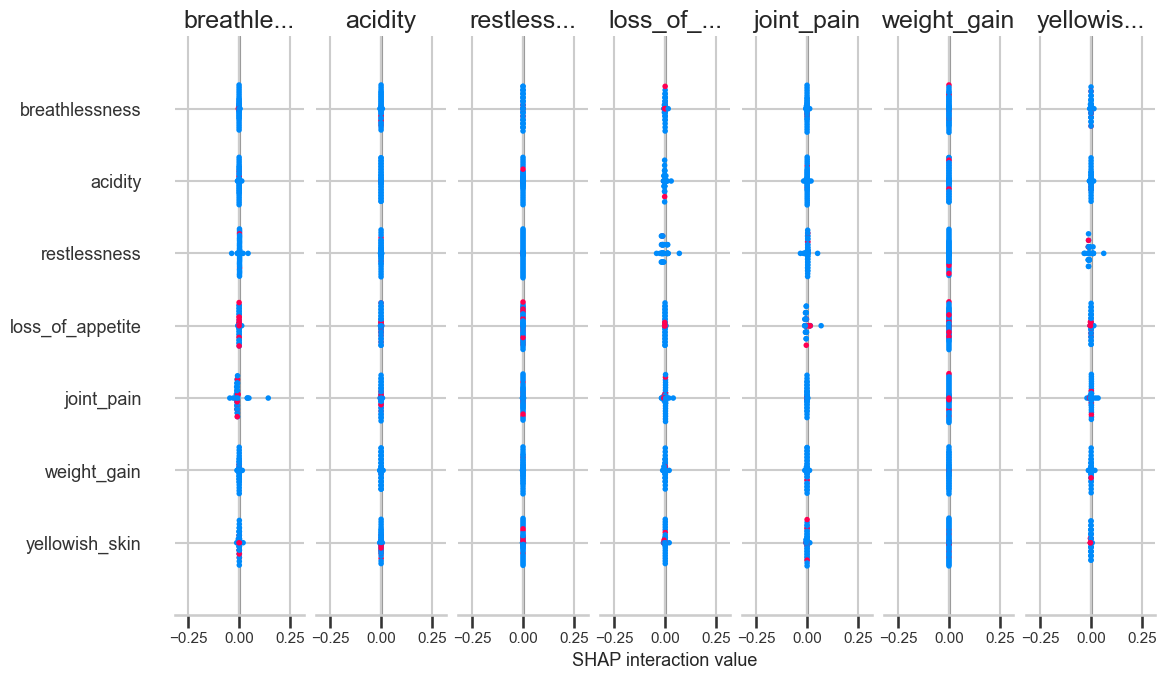

In [225]:
# Create SHAP explainer
explainer = shap.TreeExplainer(best_random_forest)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Create summary plot
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    show=False
)

# Save the figure
plt.savefig(
    OUTPUT_DIR / "shap_summary_plot.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

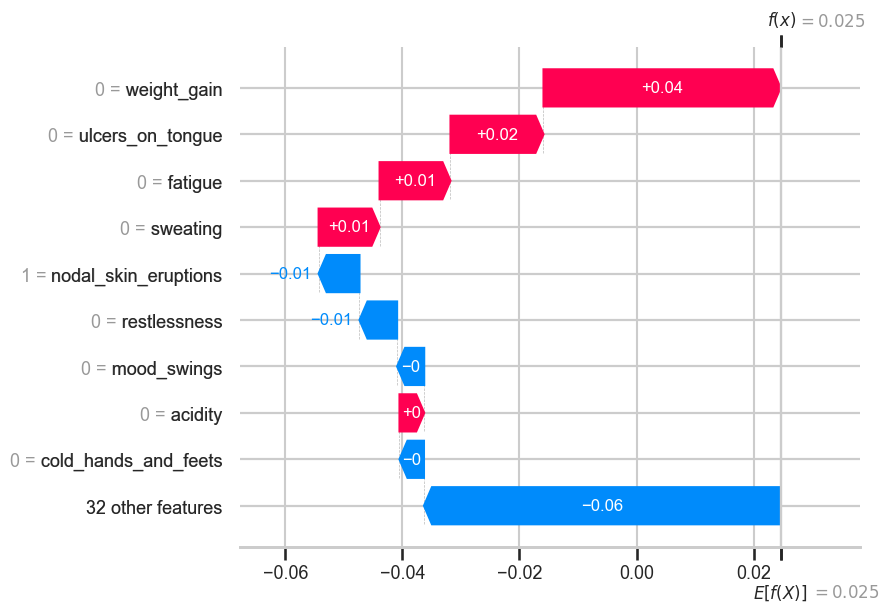

In [226]:
sample_idx = 0
class_idx = 0

explanation = shap.Explanation(
    values=shap_values[class_idx][sample_idx],
    base_values=explainer.expected_value[class_idx],
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns
)

# Create the waterfall plot
shap.plots.waterfall(explanation, show=False)

# Save the plot
plt.savefig(
    OUTPUT_DIR / "shap_waterfall_example.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

The SHAP waterfall plot provides a local explanation of the model’s prediction by showing how each symptom contributes to increasing or decreasing the predicted disease probability for an individual sample.

### 4.2 — Key Insights

Binary symptom features provide strong predictive signals. Models perform better than linear models in complex datasets. Cross-validation improves model reliability.

## Phase 5 — Project Wrap-Up

### 5.1 — Limitations

Several limitations exist in the current project.
Symptoms are simplified into binary indicators.
Real-world medical diagnosis requires more detailed patient data.
The Dataset size is relatively small.
Future work could include integrating additional medical features.

### 5.2 — Conclusion

This research shows how symptom-based datasets can be used to forecast diseases using machine learning approaches. Classification models were developed and assessed following preprocessing and exploratory analysis. Because of its ensemble structure and capacity to handle high-dimensional data, the logistic regression model performed well.

With early disease identification, such systems could be helpful aids in healthcare settings.

 #### Apendix  
Technologies Used
Tool	Purpose
Python	Programming language
Pandas	Data manipulation
NumPy	Numerical computing
Matplotlib / Seaborn	Data visualization
Scikit-learn	Machine learning models
Kaggle Dataset	Data source